In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

12404
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
aa = 1.000
bb = 1.000
eps = 1.000
eta = 0.200
xi_x = 0.000
xi_y = 0.000
xi_z = 0.000

Nt: 1024
init. cond.:   0.50   0.50   0.00 




c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:80: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


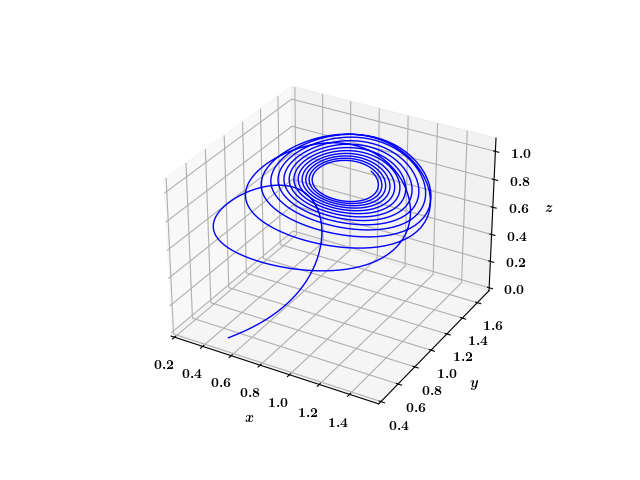

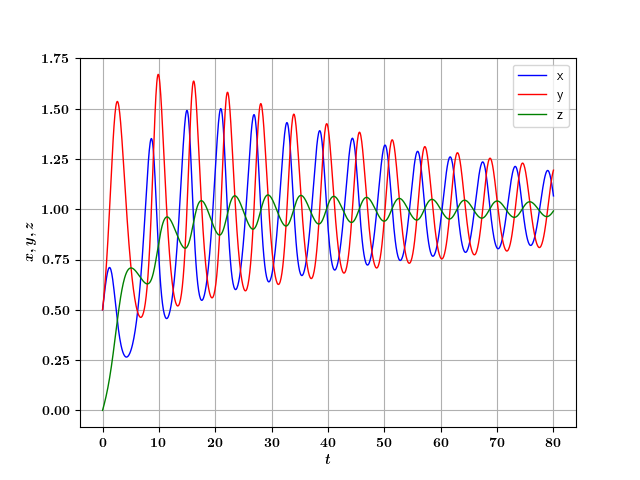

1025


In [22]:
# ---------------------------------------------------------------
# --- Prepare the system: Lotka - Volterra 3D ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    Nx2 = Nx**2 - 1
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None

    # ----------------------------------------------------
    if sel_case == 0:
        x_init = np.array([0.5, 0.5, 0.0])

        tmax, nt = 80, 10
        # aa, eps, eta, coef_re = 1.0, 0.1, 0.2, 10.
        # aa, eps, eta, coef_re = 1., 40., 1., 1.
        # aa, bb, eps, eta, coef_re = 1.0, 0.1, 0.1, 0.2, 10.
        # coef_re = 10.
        # F = [
        #     lambda x:   aa * x[0] - coef_re * bb * x[0] * x[1],
        #     lambda x:   coef_re * eps * x[0] * x[1] - coef_re * eps * x[1] * x[2],
        #     lambda x:   eta * x[1] - eta * x[2] 
        # ]

        aa, bb, eps, eta = 1.0, 1.0, 1., 0.2
        F = [
            lambda x:   aa * x[0] - bb * x[0] * x[1],
            lambda x:   eps * x[0] * x[1] - eps * x[1] * x[2],
            lambda x:   eta * x[1] - eta * x[2] 
        ]


        # --- Construct system matrices ---
        # # *** matrix F) ***
        # F_terms[0][1,0] = - c

        # # *** matrix F1 ***
        # F_terms[1][0,1], F_terms[1][1,0] = a, b

    # ----------------------------------------------------
    if sel_case == 1:
        x_init = np.array([0.5, 0.5, 0.0])
        tmax, nt = 80, 10
        # tmax, nt = 2.4, 6

        aa, bb, eps, eta = 1.0, 1.0, 1., 0.2
        xi_x, xi_y, xi_z = 0., 0., 0.

        sys_coefs = {}
        sys_coefs["aa"]    = aa
        sys_coefs["bb"]    = bb
        sys_coefs["eps"]   = eps
        sys_coefs["eta"]   = eta
        sys_coefs["xi_x"]  = xi_x
        sys_coefs["xi_y"]  = xi_y
        sys_coefs["xi_z"]  = xi_z

        def return_sys(ss):
            aa  = ss["aa"]    
            bb  = ss["bb"]    
            eps = ss["eps"]   
            eta = ss["eta"]   
            xi_x = ss["xi_x"]  
            xi_y = ss["xi_y"]  
            xi_z = ss["xi_z"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            F_terms[0][0, 0] = aa * xi_x - bb * xi_x * xi_y
            F_terms[1][0, 0] = aa - bb * xi_y
            F_terms[1][0, 1] = - bb * xi_x
            F_terms[2][0, 1] = - bb

            F_terms[0][1, 0] = eps * xi_x * xi_y - eps * xi_y * xi_z
            F_terms[1][1, 0] = eps * xi_y
            F_terms[1][1, 1] = eps * xi_x - eps * xi_z
            F_terms[1][1, 2] = - eps * xi_y
            F_terms[2][1, 1] = eps
            F_terms[2][1, 5] = - eps

            F_terms[0][2, 0] = - eta * xi_z + eta * xi_y
            F_terms[1][2, 1] = eta 
            F_terms[1][2, 2] = - eta 

            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0, 0] + F_terms[1][0, 0] * x[0] + F_terms[1][0, 1] * x[1] 
                + F_terms[2][0, 1] * x[0] * x[1],
            lambda x: F_terms[0][1, 0] + F_terms[1][1, 0] * x[0] + F_terms[1][1, 1] * x[1] + F_terms[1][1, 2] * x[2] 
                + F_terms[2][1, 1] * x[0] * x[1] + F_terms[2][1, 5] * x[1] * x[2],
            lambda x: F_terms[0][2, 0] + F_terms[1][2, 1] * x[1] + F_terms[1][2, 2] * x[2],
        ]
    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 1

N_nl_orig_ = 2 # formally assume that all considered equations are of the 3-rd order of nonlinearity
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [23]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_th = 0.1
)

The total number of variables in the embedding: 1092
--- Shift to another chart, t = 0.055 ---
radius: 0.7
zeta_gl:   0.51   0.51   0.01 
xs:      5.137e-01      5.140e-01      5.543e-03 

--- Shift to another chart, t = 0.379 ---
radius: 0.1
zeta_gl:   0.59   0.61   0.04 
xs:      7.865e-02      9.646e-02      3.483e-02 

--- Shift to another chart, t = 0.625 ---
radius: 0.1
zeta_gl:   0.64   0.70   0.07 
xs:      5.247e-02      9.084e-02      2.947e-02 

--- Shift to another chart, t = 0.870 ---
radius: 0.1
zeta_gl:   0.69   0.81   0.10 
xs:      4.023e-02      1.075e-01      3.281e-02 

--- Shift to another chart, t = 1.116 ---
radius: 0.1
zeta_gl:   0.71   0.93   0.14 
xs:      2.237e-02      1.233e-01      3.678e-02 

--- Shift to another chart, t = 1.362 ---
radius: 0.1
zeta_gl:   0.71   1.07   0.18 
xs:      2.057e-04      1.348e-01      4.124e-02 

--- Shift to another chart, t = 1.529 ---
radius: 0.1
zeta_gl:   0.69   1.16   0.21 
xs:     -1.340e-02      9.437e-02      3.076e-

write data to a file: ./jupyter-notebooks/Carleman/results//REF_LV3D_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_GL_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_GL_err_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_GL_err_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_GL_err_z.dat


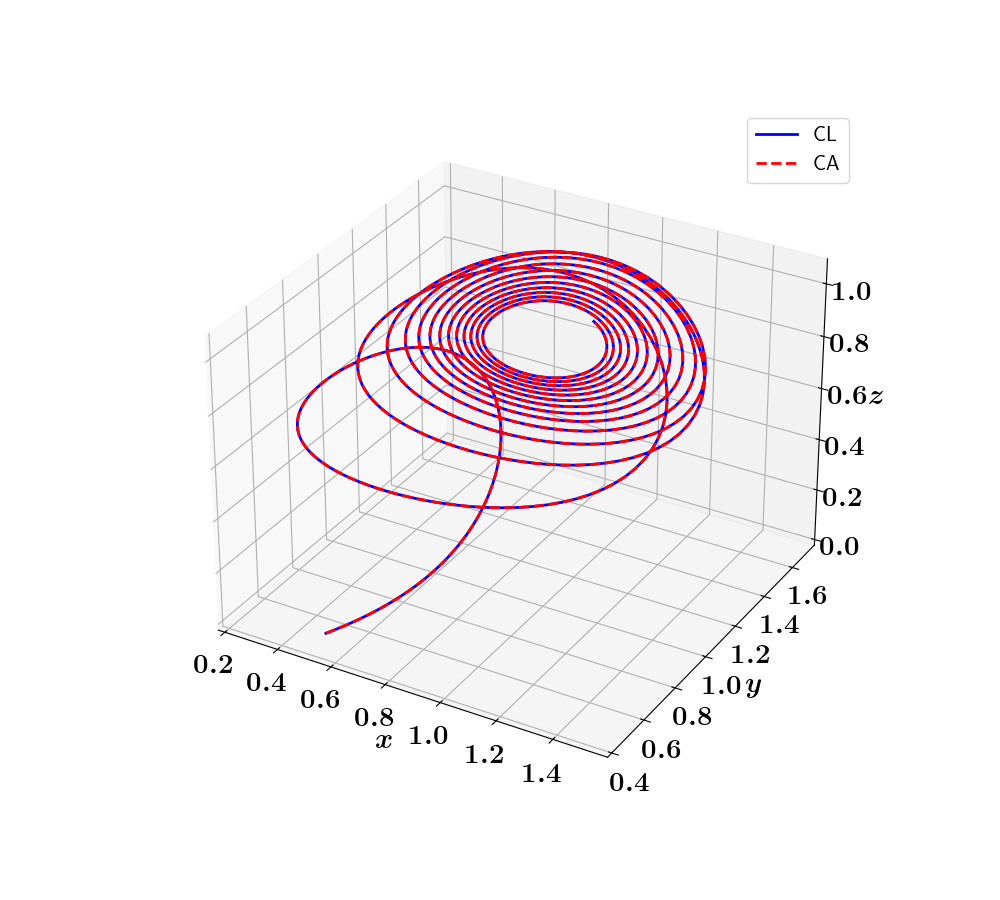

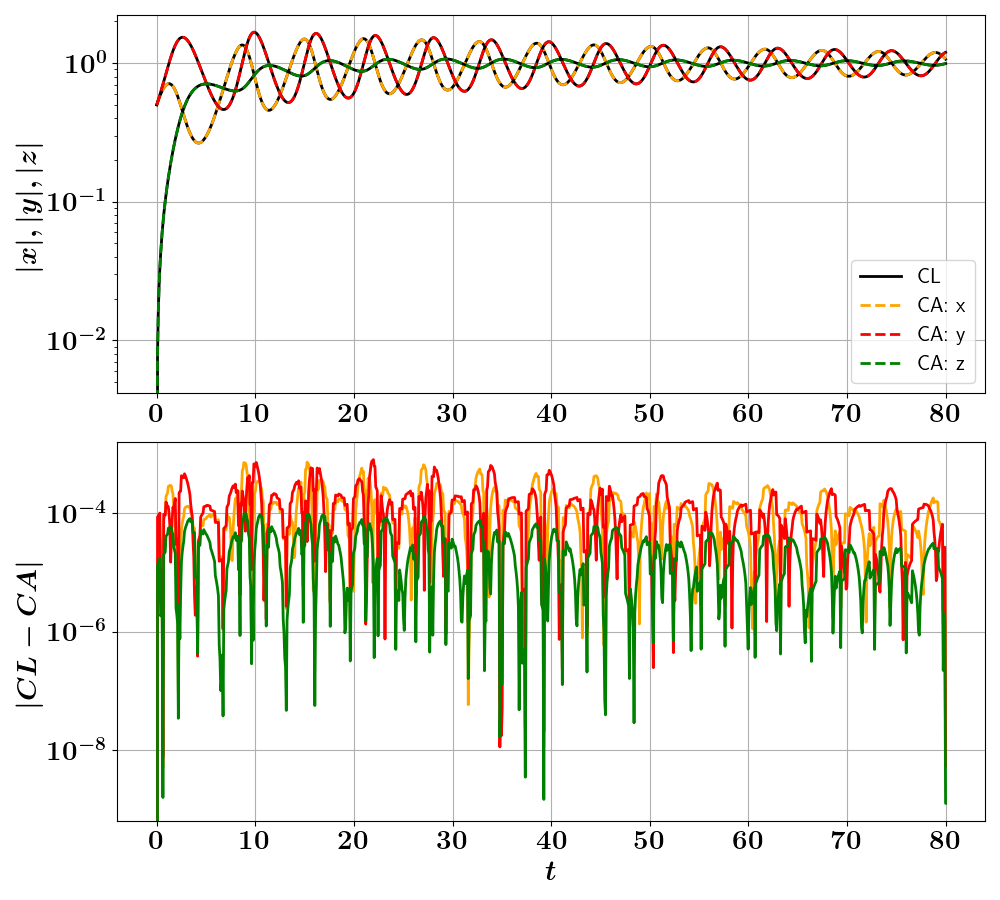

In [ ]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=False, path_save=path_save_, 
    case_title = "LV3D", case_emb = case_emb_
)